In [ ]:
%load_ext autoreload
%autoreload 2

## REMEMBER I NEED TO CHANGE THE NPX CHANNEL AND PATCH SAMPLING RATE FOR EACH CELL!!!!

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))


# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# NeuroDSP and FOOOF modules
from neurodsp import spectral
from fooof import FOOOF


# Custom modules
from lfp_spike_window_analysis import (
    compute_lfp_windows,
    map_spikes_to_windows,
    combine_spike_lfp_features
)
from spikeparam.patch.fit import Spike


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_19001/4079802822.py:20: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
cell_num_list = [6, 7,8,14, 15, 16, 18, 19, 20, 21, 22, 24, 27, 14,44,45]
patch_fs_list = [50023.89817284,50023.91361167,50023.90949465,50023.89868747,50023.89405582,50023.90270156,50023.89199731,
                 50023.88376327,50023.87964625,50023.89714358,50023.89474199,50023.89405582,50023.88788029,50023.88170476,50023.87244147,50023.87347073]

chan_pred_list = [172,188,188,159,183,220,157,178,199,180,205,248,223,108,178,178]


dict_patch_fs = dict(zip(cell_num_list, patch_fs_list))

dict_chan_pred = dict(zip(cell_num_list, chan_pred_list ))

In [4]:
cell_ids = 'c14'
cell_num =14

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs_c14 = dict_patch_fs[cell_num ]

npx_channels = 384
npx_patch_channel = dict_chan_pred[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 14  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 14

## Step 0: Get loaded data

In [5]:
lfp_c14= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c14_lfp_filt.npy'
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'


In [6]:
#get cell number 
cell_num = lfp_c14.split('/')[len(lfp_c14.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt_c14 = np.load(lfp_c14)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times_c14 = np.arange(0, np.shape(lfp_filt_c14)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec

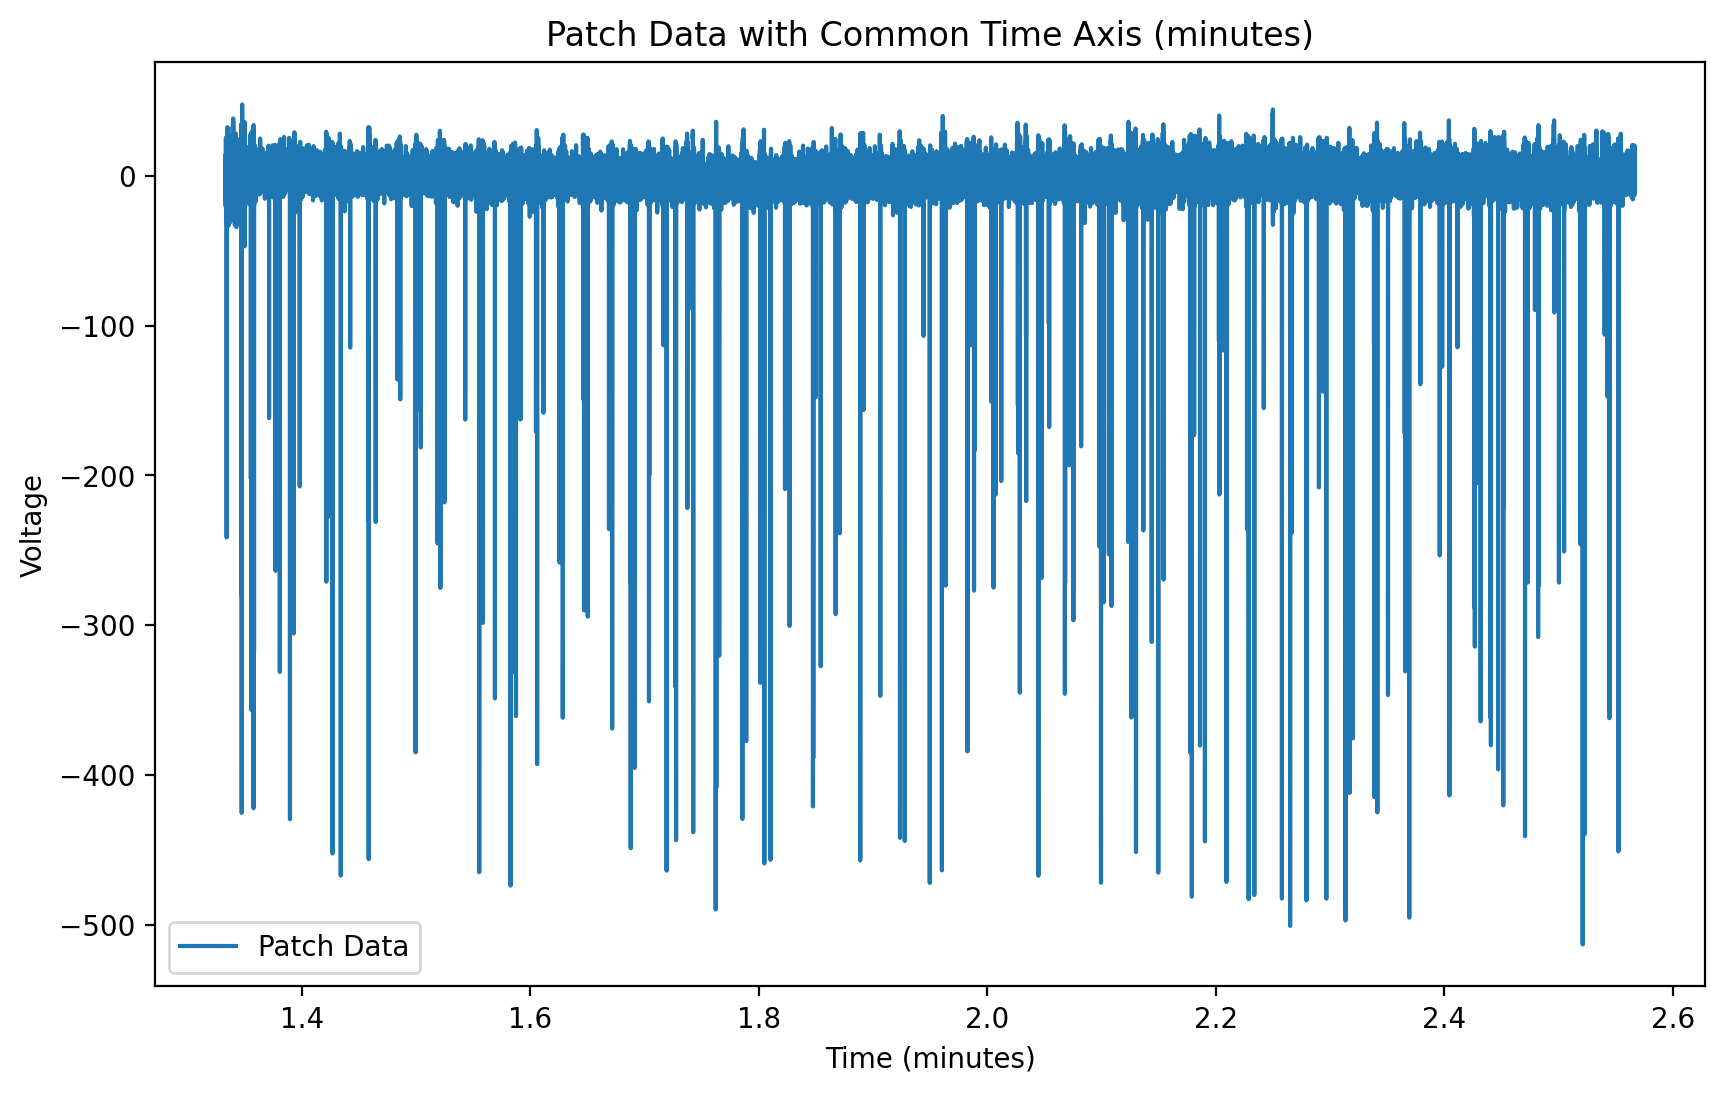

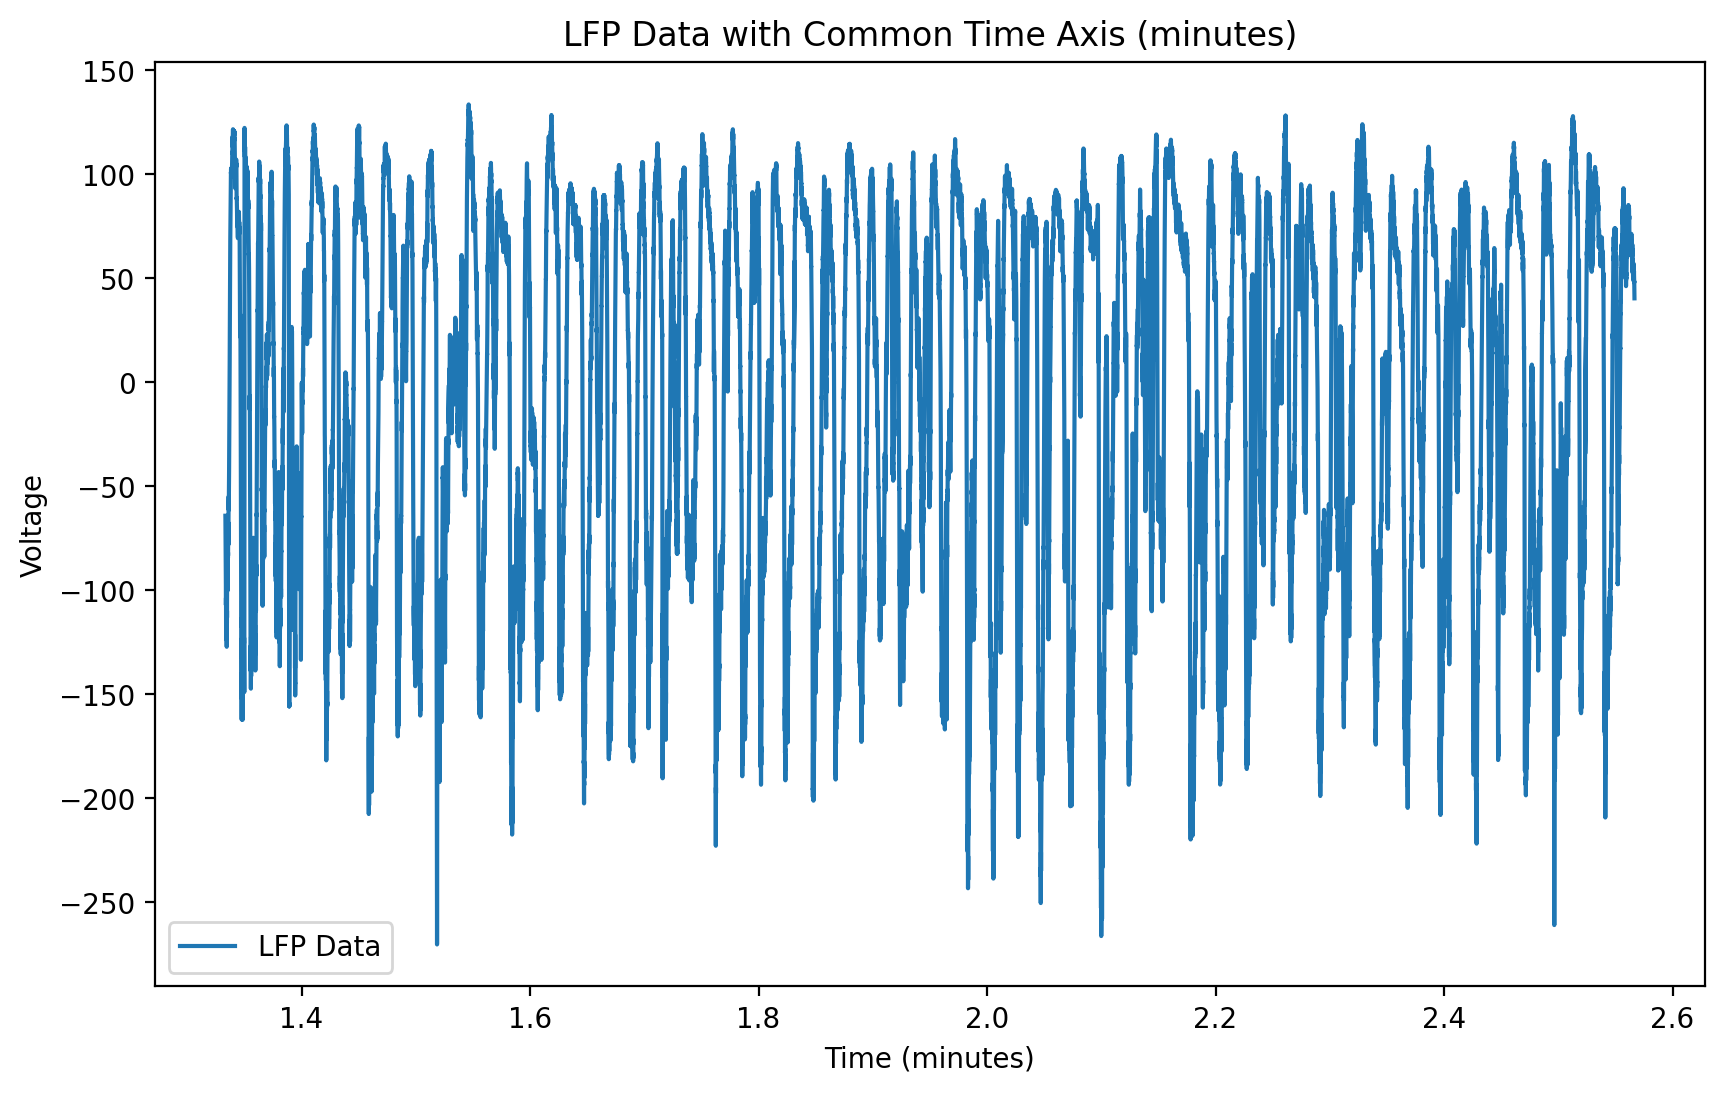

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times_c14 / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times_c14 / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt_c14)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt_c14)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

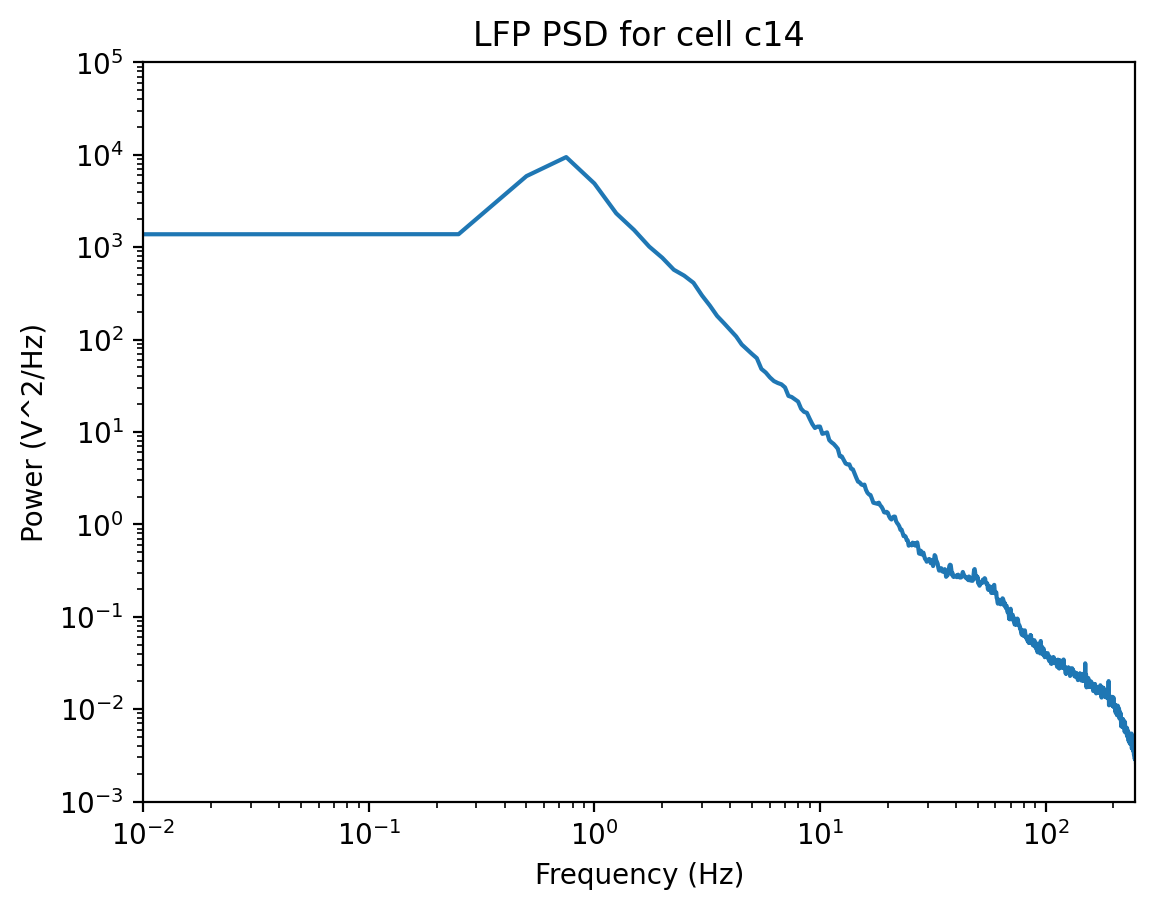

In [8]:
#plot PSD for cell 14
# plot power spectrum
fxx_c14, pxx_c14 = spectral.compute_spectrum(lfp_filt_c14, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c14, pxx_c14)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


###### SLIDING WINDOWS APPROACH

In [23]:

# Set parameters for the analysis
window_length_sec = 25  # Length of each window in seconds
step_size_sec = 12.5      # Step size in seconds
freq_range = (1, 90)    # Frequency range for FOOOF fitting
fooof_params = {
    "max_n_peaks": 4,
    "verbose": False
}  # Adjust FOOOF parameters as needed

# Call the function
spectra, foof_results, window_times = compute_lfp_windows(
    lfp_signal=lfp_filt_c14,
    fs=lfp_fs,
    window_length_sec=window_length_sec,
    step_size_sec=step_size_sec,
    freq_range=freq_range,
    fooof_params=fooof_params,
    plot=False # Set to True if you want to see the power spectrum plots
)

# spectra and foof_results now contain the results


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## STEP 2: Detect spikes from patch data

In [10]:
#flip sign of patch filt
patch_filt_c14 = -patch_filt_c14

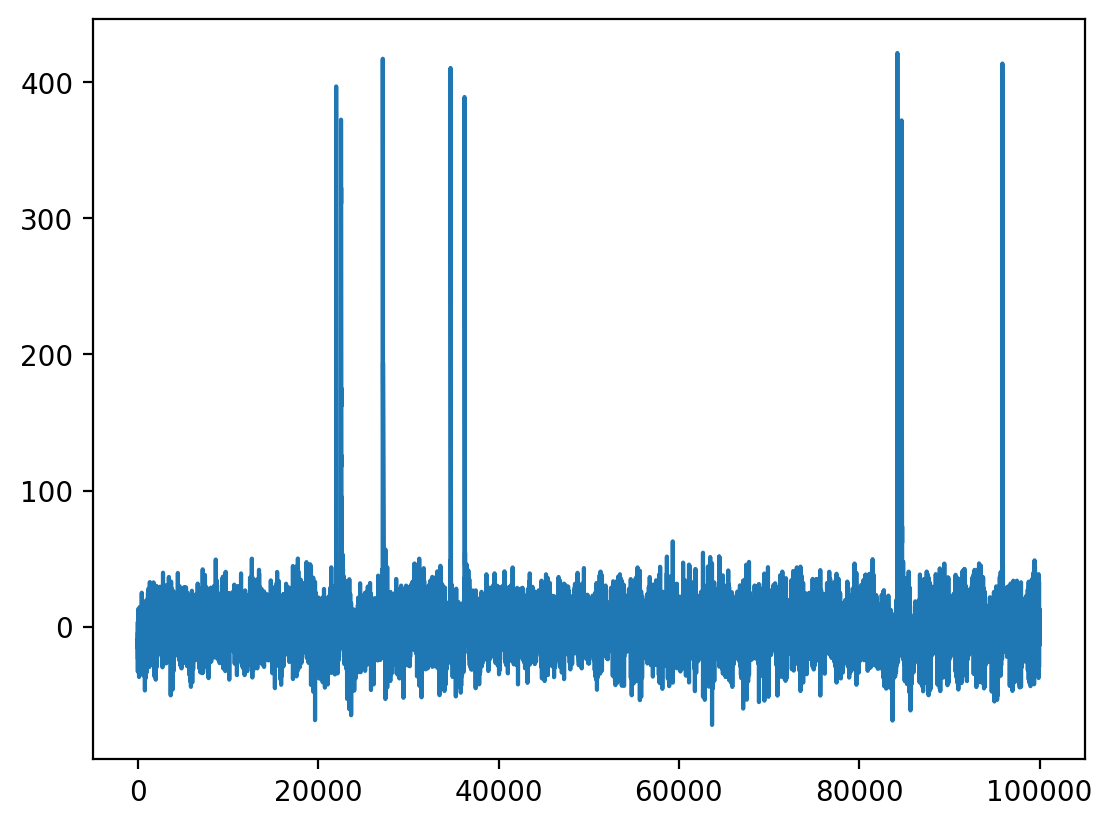

In [11]:
plt.plot(patch_filt_c14[:100000] )

In [12]:
#threshold in mVs
sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)


sp.fit(patch_filt_c14, patch_fs_c14, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/4504 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Get spike dataframe (with spike times column)

In [13]:
df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times_c14[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,spk_times_idx,spk_times_ms,spk_id
0,10.961877,0.30,18.382591,395.951470,0.62,79.815607,3.948221,-7.969183,103.270674,0.105688,0.931976,21998,4.397500e+02,0
1,11.199288,0.30,25.167280,410.769554,0.58,38.602095,3.252342,10.962803,150.208255,0.100877,0.931059,27164,5.430206e+02,1
2,18.679983,0.26,-16.844094,380.923194,0.66,104.931446,2.765641,-9.252601,31.025181,0.203775,0.951483,34678,6.932289e+02,2
3,27.569676,0.36,24.323961,386.861926,0.68,51.947039,2.844247,16.399738,959.521700,0.477906,0.940651,36230,7.242541e+02,3
4,11.695804,0.30,7.862321,412.076375,0.50,73.183001,5.008925,-3.030722,232.788812,0.147446,0.899183,84229,1.683776e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4499,2.848800,0.22,19.315945,609.326668,0.44,245.773541,2.264784,6.655033,74.064624,0.011678,0.978297,53993410,1.079353e+06,4499
4500,7.844780,0.24,36.468800,539.096360,0.48,182.731819,2.330059,27.294306,95.194532,0.077243,0.970840,53997115,1.079427e+06,4500
4501,21.334144,0.24,34.382807,642.778547,0.46,256.968232,1.976378,15.565057,50.815729,0.441055,0.984444,54001877,1.079522e+06,4501
4502,11.457567,0.24,22.811053,599.141551,0.46,239.975334,1.980195,14.101782,394.631511,0.145509,0.982903,54004419,1.079573e+06,4502


### Filter spike dataframe 

In [15]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

In [16]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,10.961877,0.30,18.382591,395.951470,0.62,79.815607,3.948221,-7.969183,2.013977,21998,4.397500e+02,0
1,11.199288,0.30,25.167280,410.769554,0.58,38.602095,3.252342,10.962803,2.176694,27164,5.430206e+02,1
2,18.679983,0.26,-16.844094,380.923194,0.66,104.931446,2.765641,-9.252601,1.491714,34678,6.932289e+02,2
3,27.569676,0.36,24.323961,386.861926,0.68,51.947039,2.844247,16.399738,2.982055,36230,7.242541e+02,3
4,11.695804,0.30,7.862321,412.076375,0.50,73.183001,5.008925,-3.030722,2.366962,84229,1.683776e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4496,10.949014,0.22,30.747441,500.183396,0.56,171.615948,1.280002,2.863478,2.762231,53960086,1.078687e+06,4496
4497,16.978687,0.22,25.482944,635.452971,0.44,254.095983,2.919568,-6.782038,1.301257,53989020,1.079265e+06,4497
4498,16.588745,0.24,33.900754,592.427963,0.46,217.024450,1.659292,15.158946,1.830894,53990021,1.079285e+06,4498
4501,21.334144,0.24,34.382807,642.778547,0.46,256.968232,1.976378,15.565057,1.705998,54001877,1.079522e+06,4501


### Get spike times (only times for only spikes remaining postfiltering)


In [17]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 3: Align spikes to lfp windows

In [18]:
spike_to_window_map = map_spikes_to_windows(spk_times_ms, spk_ids, window_times, df_features['spk_id'], lfp_fs)


### Visualize spikes and lfp windows 

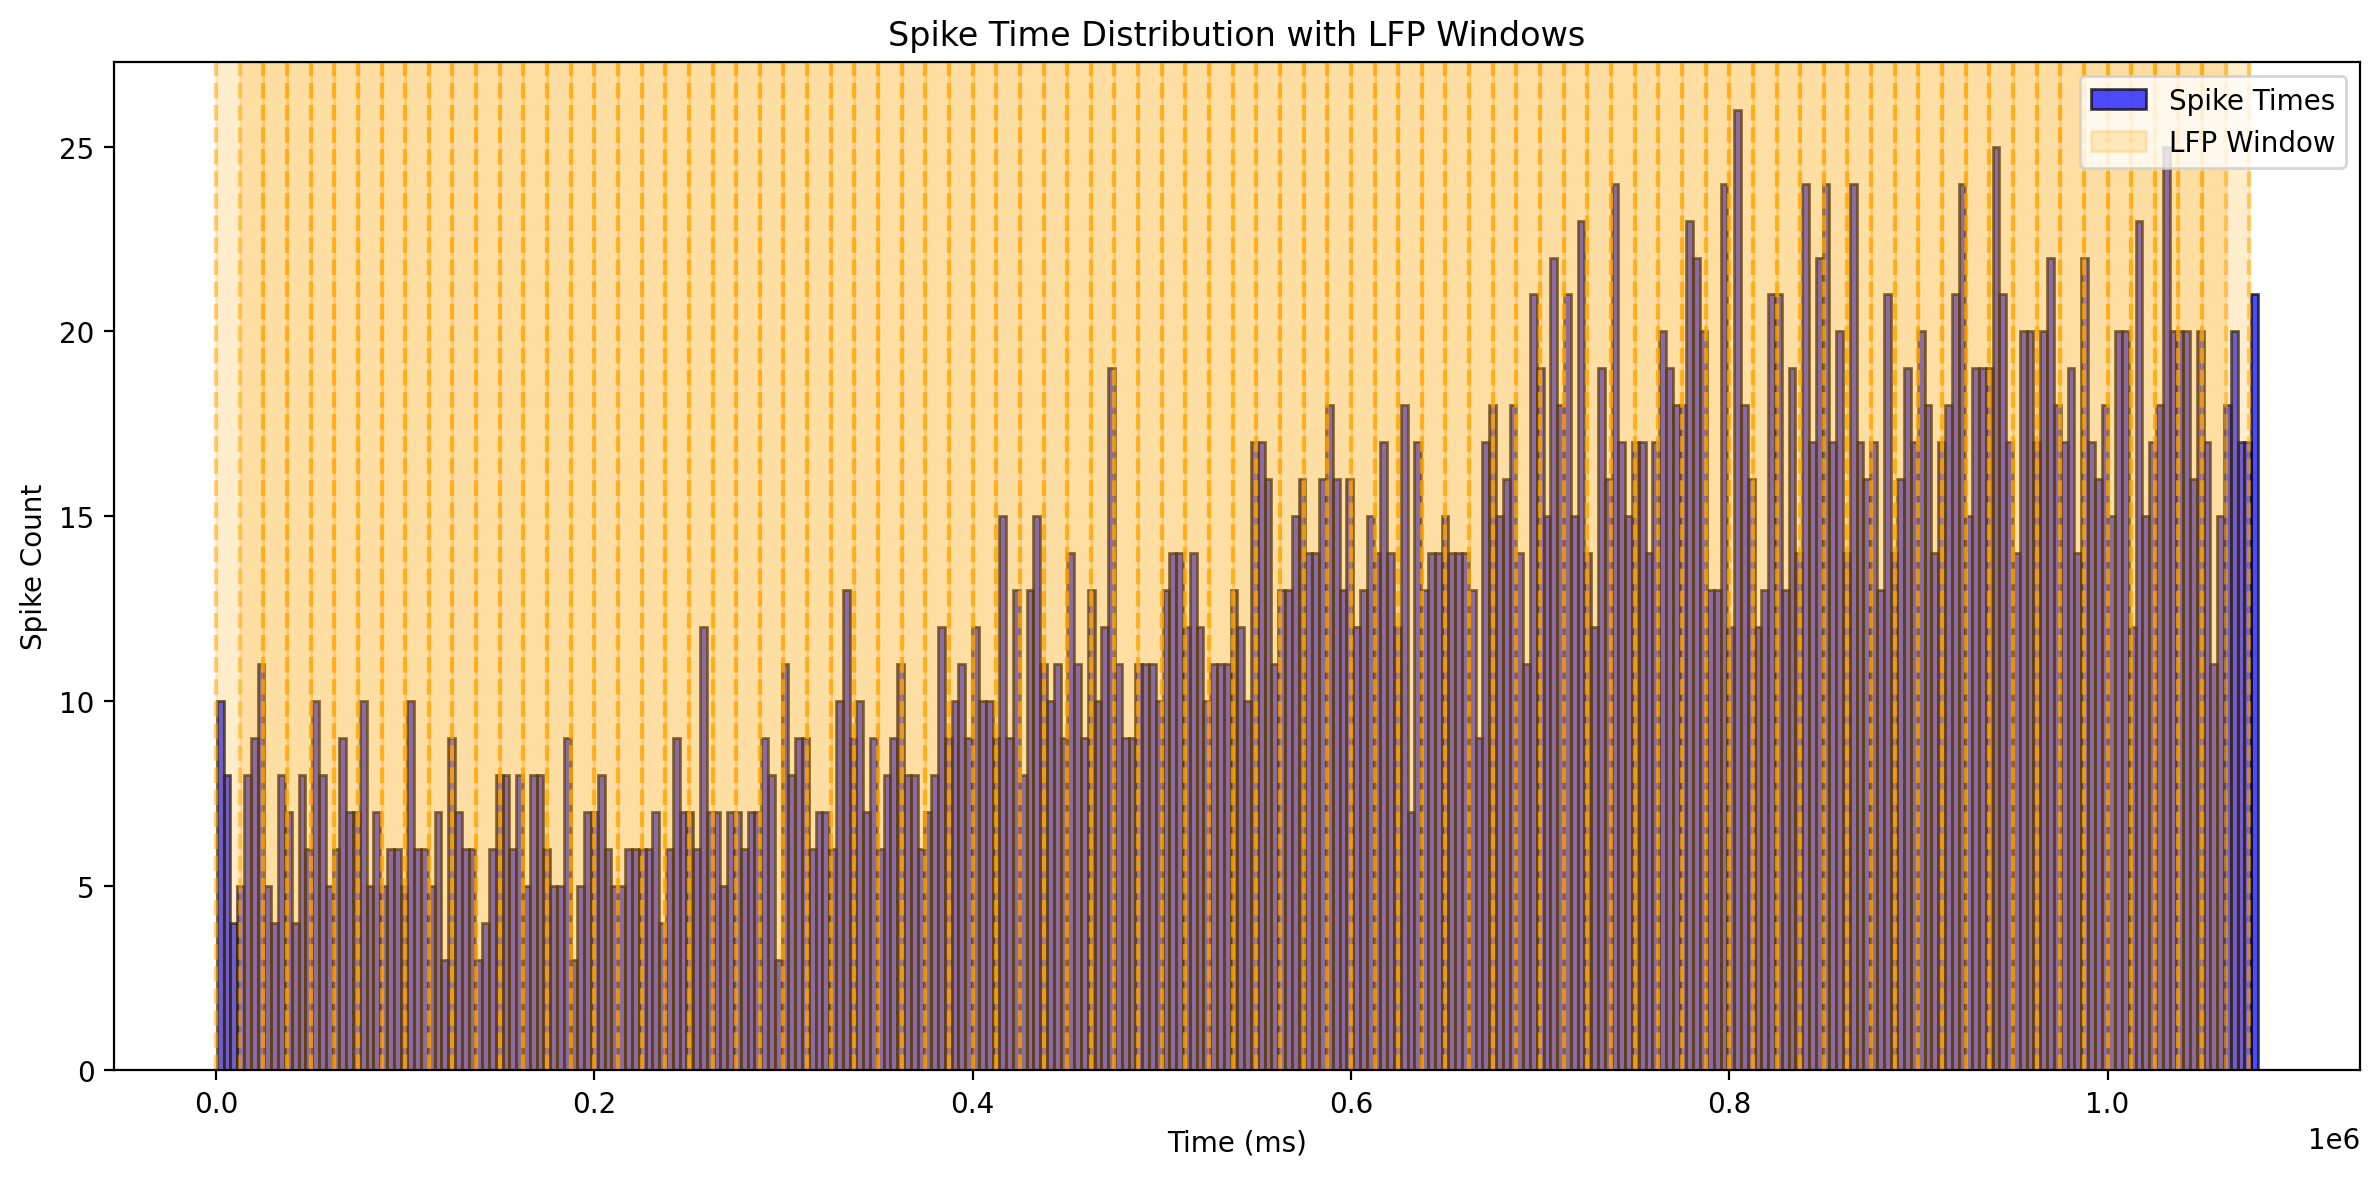

In [19]:
# Plot the histogram of spike times
plt.figure(figsize=(12, 6))
plt.hist(spk_times_ms, bins=300, color='blue', alpha=0.7, edgecolor='black', label="Spike Times")

# Overlay the LFP windows with reduced opacity
for idx, (start, end) in enumerate(window_times):  # window_times contains (start, end) in samples
    start_ms = start / lfp_fs * 1000  # Convert start to ms
    end_ms = end / lfp_fs * 1000      # Convert end to ms
    plt.axvspan(start_ms, end_ms, color='orange', alpha=0.2, label='LFP Window' if idx == 0 else "")

# Optionally, add vertical lines to mark edges of windows
for start, end in window_times:
    start_ms = start / lfp_fs * 1000  # Convert start to ms
    end_ms = end / lfp_fs * 1000      # Convert end to ms
    plt.axvline(start_ms, color='orange', linestyle='--', alpha=0.5)
    plt.axvline(end_ms, color='orange', linestyle='--', alpha=0.5)

# Add labels and legend
plt.xlabel("Time (ms)")
plt.ylabel("Spike Count")
plt.title("Spike Time Distribution with LFP Windows")
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()



## STEP 4: COMBINE SPIKE DATAFRAME WITH LFP FEATURES (FOR CURRENT WINDOW AND PREVIOUS WINDOW)

In [30]:
# After mapping spikes to windows
df_combined_spk_lfp = combine_spike_lfp_features(
    spike_data=df_features,
    foof_results=foof_results,
    spike_to_window_map=spike_to_window_map
)



In [32]:
df_combined_spk_lfp[:3000]


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,...,lfp_current_offset,lfp_current_exponent,lfp_current_r_squared,lfp_current_error,lfp_current_n_peaks,lfp_previous_offset,lfp_previous_exponent,lfp_previous_r_squared,lfp_previous_error,lfp_previous_n_peaks
0,10.961877,0.30,18.382591,395.951470,0.62,79.815607,3.948221,-7.969183,2.013977,21998,...,[3.072020892607564],[2.3128437391540855],[0.9512826454456292],[0.16905339182948226],[3],[None],[None],[None],[None],[None]
1,11.199288,0.30,25.167280,410.769554,0.58,38.602095,3.252342,10.962803,2.176694,27164,...,[3.072020892607564],[2.3128437391540855],[0.9512826454456292],[0.16905339182948226],[3],[None],[None],[None],[None],[None]
2,18.679983,0.26,-16.844094,380.923194,0.66,104.931446,2.765641,-9.252601,1.491714,34678,...,[3.072020892607564],[2.3128437391540855],[0.9512826454456292],[0.16905339182948226],[3],[None],[None],[None],[None],[None]
3,27.569676,0.36,24.323961,386.861926,0.68,51.947039,2.844247,16.399738,2.982055,36230,...,[3.072020892607564],[2.3128437391540855],[0.9512826454456292],[0.16905339182948226],[3],[None],[None],[None],[None],[None]
4,11.695804,0.30,7.862321,412.076375,0.50,73.183001,5.008925,-3.030722,2.366962,84229,...,[3.072020892607564],[2.3128437391540855],[0.9512826454456292],[0.16905339182948226],[3],[None],[None],[None],[None],[None]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3577,17.193338,0.26,25.226601,535.914631,0.54,157.166306,2.195545,12.244270,1.663682,46121605,...,"[3.3246905703327005, 3.1598160984172448]","[2.487415222805569, 2.2468905981311407]","[0.9399179777750915, 0.9485700766537897]","[0.18252445927424046, 0.15374536585701987]","[3, 3]","[3.2429966347702317, 3.3246905703327005]","[2.4666759138478542, 2.487415222805569]","[0.9286521849709999, 0.9399179777750915]","[0.1936177420677823, 0.18252445927424046]","[3, 3]"
3578,20.109595,0.26,10.189069,521.538226,0.58,164.239262,1.632634,3.889941,1.594848,46123911,...,"[3.3246905703327005, 3.1598160984172448]","[2.487415222805569, 2.2468905981311407]","[0.9399179777750915, 0.9485700766537897]","[0.18252445927424046, 0.15374536585701987]","[3, 3]","[3.2429966347702317, 3.3246905703327005]","[2.4666759138478542, 2.487415222805569]","[0.9286521849709999, 0.9399179777750915]","[0.1936177420677823, 0.18252445927424046]","[3, 3]"
3579,22.545192,0.26,29.613177,498.460086,0.58,140.972658,1.769291,24.118320,2.509962,46125879,...,"[3.3246905703327005, 3.1598160984172448]","[2.487415222805569, 2.2468905981311407]","[0.9399179777750915, 0.9485700766537897]","[0.18252445927424046, 0.15374536585701987]","[3, 3]","[3.2429966347702317, 3.3246905703327005]","[2.4666759138478542, 2.487415222805569]","[0.9286521849709999, 0.9399179777750915]","[0.1936177420677823, 0.18252445927424046]","[3, 3]"
3580,16.813123,0.24,26.456897,568.374304,0.50,201.433277,2.362064,-7.269321,1.317856,46142065,...,"[3.3246905703327005, 3.1598160984172448]","[2.487415222805569, 2.2468905981311407]","[0.9399179777750915, 0.9485700766537897]","[0.18252445927424046, 0.15374536585701987]","[3, 3]","[3.2429966347702317, 3.3246905703327005]","[2.4666759138478542, 2.487415222805569]","[0.9286521849709999, 0.9399179777750915]","[0.1936177420677823, 0.18252445927424046]","[3, 3]"
